# Data Analysis

# 0. Package Import :

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
import pickle as pickle
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import sklearn.preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import sklearn.preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


# 1. Business and Data Understanding:

### this step aims to identify:

###### Read Data

In [145]:
file_path = r"C:\pfe\fraud_detection_dataset.csv" 
df = pd.read_csv(file_path) 
# 1. Read fresh




# Check if amount or other columns correlate with is_fraud
print(df[['amount', 'age', 'income', 'debt', 'credit_score', 'is_fraud']].corr()['is_fraud'].sort_values(ascending=False))

is_fraud        1.000000
amount          0.829145
credit_score    0.000427
debt            0.000149
income          0.000016
age            -0.000697
Name: is_fraud, dtype: float64


###### First five rows 

In [3]:

print(df.head())

             timestamp                               user_id  amount  \
0  2023-12-15 02:48:24  3cbf0b8a-c799-4c0e-9782-89272ab8fa2b  998.99   
1  2023-10-30 11:08:37  3675ed98-6863-4bae-b089-6f0db2df006b  241.39   
2  2023-11-21 05:19:35  4be1043f-20ee-4ac5-a689-b25c6a1de50c  836.42   
3  2023-11-07 00:03:25  cad0b3c9-099f-479b-8043-6d5ecb4e1467  612.74   
4  2023-04-02 14:12:23  b6ebea7d-ba62-41d7-b042-3978a23fef8b  135.55   

          location device_type  is_fraud  age     income      debt  \
0        Grantfurt      Mobile         0   56   42524.98   8394.05   
1  Kimberlychester      Tablet         0   52   69884.04  28434.06   
2   Gutierrezville     Desktop         0   58  126953.62  39121.78   
3         Markside     Desktop         0   19  128650.70  39652.48   
4     Anthonyshire      Tablet         0   59  102020.39   7439.81   

   credit_score  
0           655  
1           395  
2           496  
3           612  
4           302  


###### info data 

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 10 columns):
 #   Column        Dtype  
---  ------        -----  
 0   timestamp     str    
 1   user_id       str    
 2   amount        float64
 3   location      str    
 4   device_type   str    
 5   is_fraud      int64  
 6   age           int64  
 7   income        float64
 8   debt          float64
 9   credit_score  int64  
dtypes: float64(3), int64(3), str(4)
memory usage: 152.6 MB


In [5]:
# Convert timestamp to datetime (if not already)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract time features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()

# Create age groups (adjust bins if needed)
df['age_group'] = pd.cut(
    df['age'],
    bins=[0, 18, 30, 40, 50, 60, 100],
    labels=['<18', '18-30', '31-40', '41-50', '51-60', '60+'],
    right=False
)

# Null values
null_counts = df.isnull().sum()
null_percent = (null_counts / len(df)) * 100

print("Valeurs nulles par colonne :")
print(null_counts)

print("\nPourcentage des valeurs nulles :")
print(null_percent)

# Duplicates
print("\nNombre de doublons :", df.duplicated().sum())


Valeurs nulles par colonne :
timestamp       0
user_id         0
amount          0
location        0
device_type     0
is_fraud        0
age             0
income          0
debt            0
credit_score    0
hour            0
day_of_week     0
age_group       0
dtype: int64

Pourcentage des valeurs nulles :
timestamp       0.0
user_id         0.0
amount          0.0
location        0.0
device_type     0.0
is_fraud        0.0
age             0.0
income          0.0
debt            0.0
credit_score    0.0
hour            0.0
day_of_week     0.0
age_group       0.0
dtype: float64

Nombre de doublons : 0


###### number of rows and columns

In [6]:
df.shape

(2000000, 13)

###### info class fraud vs no fraud

In [7]:
df.is_fraud.unique()

array([0, 1], dtype=int64)

###### is_fraud plot 

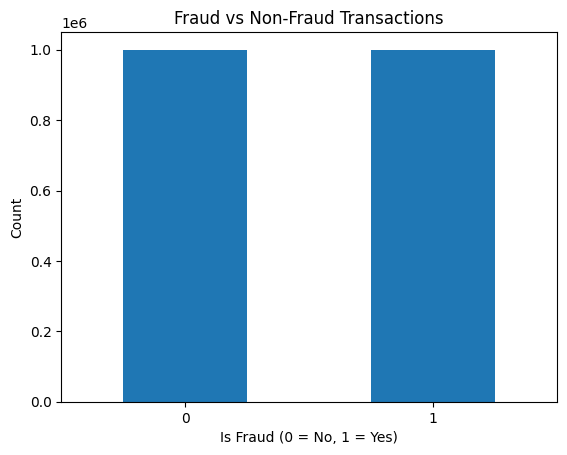

In [8]:
plt.figure()
df["is_fraud"].value_counts().plot(kind="bar")
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

### 3.2.2 Preprocessing 

###### Encoding

In [9]:
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

In [10]:
print(df.dtypes)

timestamp       datetime64[us]
user_id                    str
amount                 float64
location                   str
device_type                str
is_fraud                 int64
age                      int64
income                 float64
debt                   float64
credit_score             int64
hour                     int32
day_of_week                str
age_group             category
dtype: object


In [11]:
print(df.select_dtypes(include=['int64', 'float64']).columns)

Index(['amount', 'is_fraud', 'age', 'income', 'debt', 'credit_score'], dtype='str')


In [12]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numerical_cols.remove('is_fraud')

### Show Characteristics for column timestamp 

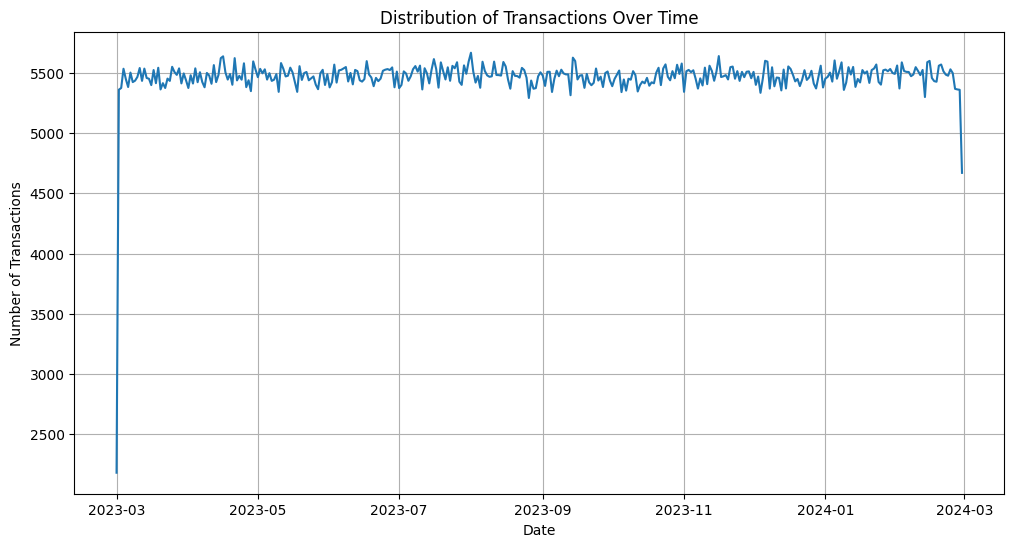

In [13]:

df['timestamp'] = pd.to_datetime(df['timestamp'])


df['date'] = df['timestamp'].dt.date


daily_counts = df.groupby('date').size()


plt.figure(figsize=(12,6))
daily_counts.plot(kind='line')  
plt.title('Distribution of Transactions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Transactions')
plt.grid(True)
plt.show()

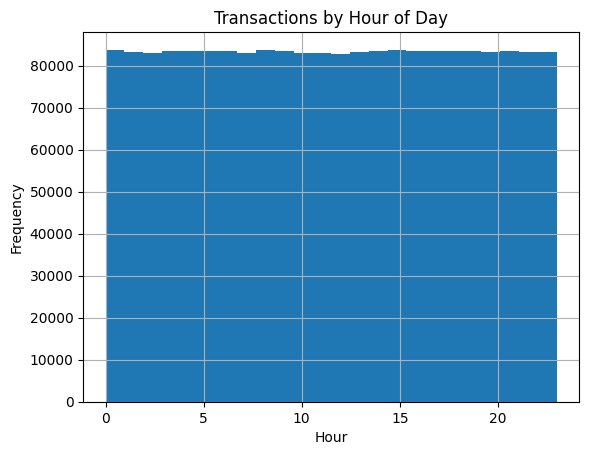

In [14]:
plt.figure()
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp"].dt.hour.hist(bins=24)
plt.title("Transactions by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Frequency")
plt.show()


### When Fraud Happens By Time

###### | 🌙 **Night**     | 00:00 ≤ hour < 06:00    | 12:00 AM – 5:59 AM  | 🌅 **Morning**   | 06:00 ≤ hour < 12:00    | 6:00 AM – 11:59 AM || 🌇 **Afternoon** | 12:00 ≤ hour < 18:00    | 12:00 PM – 5:59 PM || 🌃 **Evening**   | 18:00 ≤ hour < 24:00    | 6:00 PM – 11:59 PM |


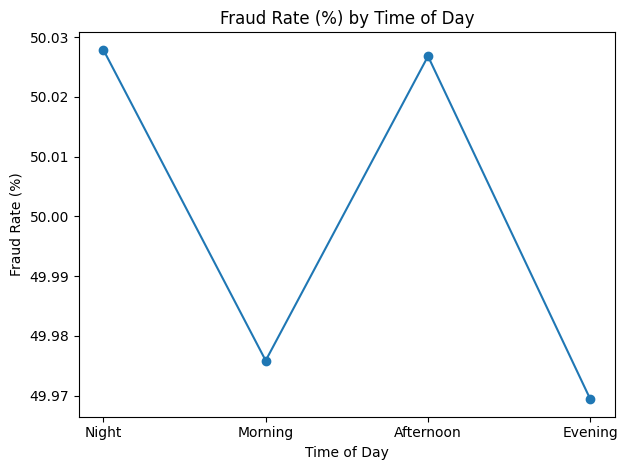

In [15]:
# Extract hour
df['hour'] = pd.to_datetime(df['timestamp']).dt.hour

# Create time-of-day groups for ALL transactions
df['time_period'] = pd.cut(
    df['hour'],
    bins=[0, 6, 12, 18, 24],
    labels=["Night", "Morning", "Afternoon", "Evening"],
    right=False
)

# Calculate fraud rate per time period
fraud_rate_time = (
    df.groupby('time_period')['is_fraud']
    .mean()
    .reset_index()
)

# Convert to percentage
fraud_rate_time['fraud_rate_percent'] = fraud_rate_time['is_fraud'] * 100

# Plot as line
plt.figure()
plt.plot(fraud_rate_time['time_period'], 
         fraud_rate_time['fraud_rate_percent'], 
         marker='o')

plt.title("Fraud Rate (%) by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

### Characteristics For Column Amount 

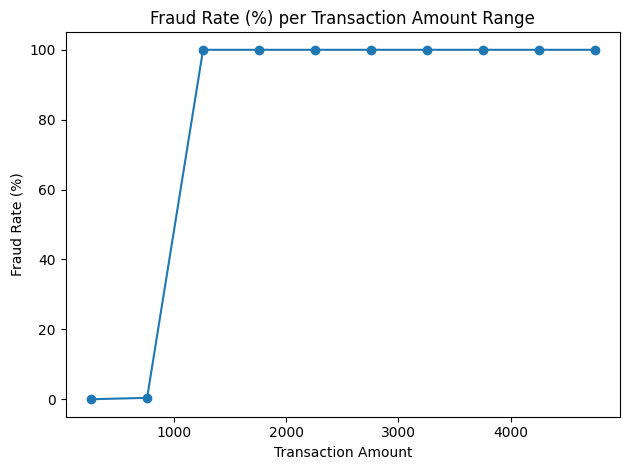

In [16]:
# Create amount bins (10 equal-width ranges)
df['amount_bin'] = pd.cut(df['amount'], bins=10)

# Calculate fraud rate per amount range
fraud_rate_amount = (
    df.groupby('amount_bin')['is_fraud']
    .mean()
    .reset_index()
)

# Convert to percentage
fraud_rate_amount['fraud_rate_percent'] = fraud_rate_amount['is_fraud'] * 100

# Use bin midpoints for plotting
fraud_rate_amount['bin_mid'] = fraud_rate_amount['amount_bin'].apply(lambda x: x.mid)

# Plot
plt.figure()
plt.plot(fraud_rate_amount['bin_mid'], fraud_rate_amount['fraud_rate_percent'], marker='o')

plt.title("Fraud Rate (%) per Transaction Amount Range")
plt.xlabel("Transaction Amount")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

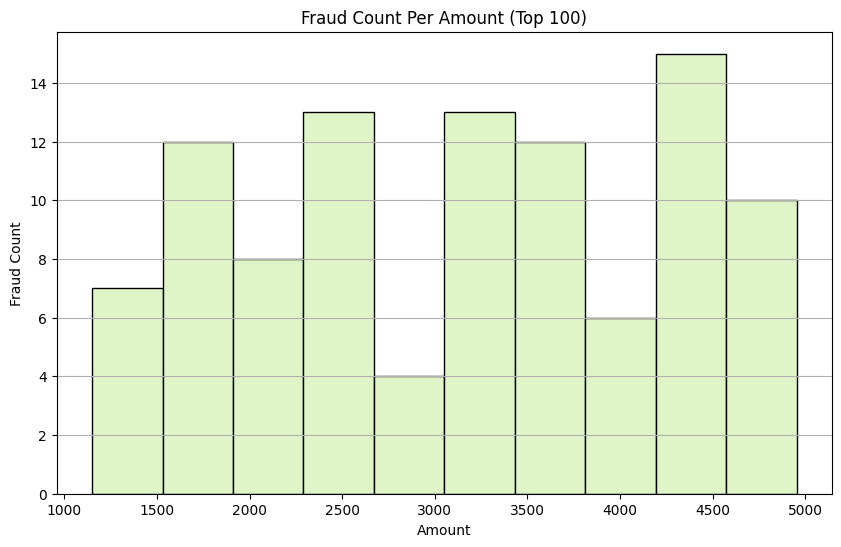

In [17]:
# Filtrer seulement les fraudes
df_fraud = df[df['is_fraud']==1]

# Prendre un échantillon top 100 pour lisibilité
df_sample = df_fraud['amount'].sample(100, random_state=42)

# Histogramme avec couleur nude
plt.figure(figsize=(10,6))
plt.hist(df_sample, bins=10, color="#DFF5C8", edgecolor='black')  # couleur nude
plt.title("Fraud Count Per Amount (Top 100)")
plt.xlabel("Amount")
plt.ylabel("Fraud Count")
plt.grid(axis='y')
plt.show()

### Characteristics For Column Location 

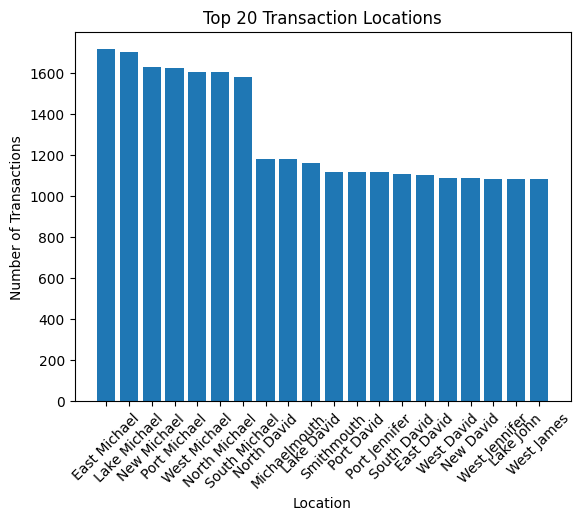

In [18]:
top_locations = df["location"].value_counts().nlargest(20)

plt.figure()
plt.bar(top_locations.index.astype(str), top_locations.values)
plt.title("Top 20 Transaction Locations")
plt.xlabel("Location")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)

plt.show()



### top 10 fraud rate per location

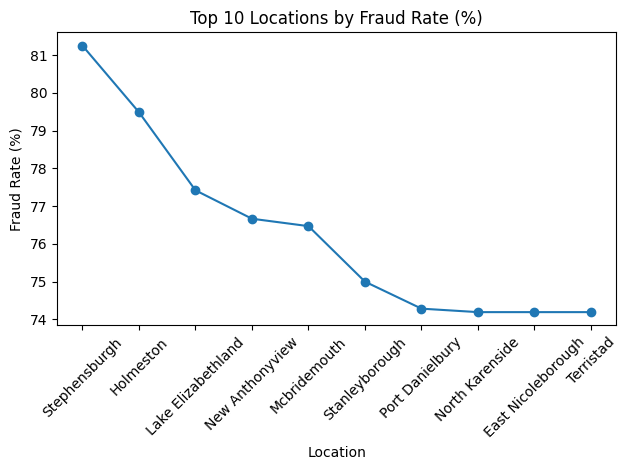

In [19]:


grouped = df.groupby("location")["is_fraud"].agg(["mean", "count"])

# Keep only locations with enough transactions
grouped = grouped[grouped["count"] >= 30]

# Sort by fraud rate
sorted_data = grouped.sort_values("mean", ascending=False)

# Take top 10
top10 = sorted_data.head(10)

# Convert to percentage
fraud_percent = top10["mean"] * 100

plt.figure()
plt.plot(top10.index, fraud_percent, marker='o')

plt.title("Top 10 Locations by Fraud Rate (%)")
plt.xlabel("Location")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()



### lowest fraud rates per location 

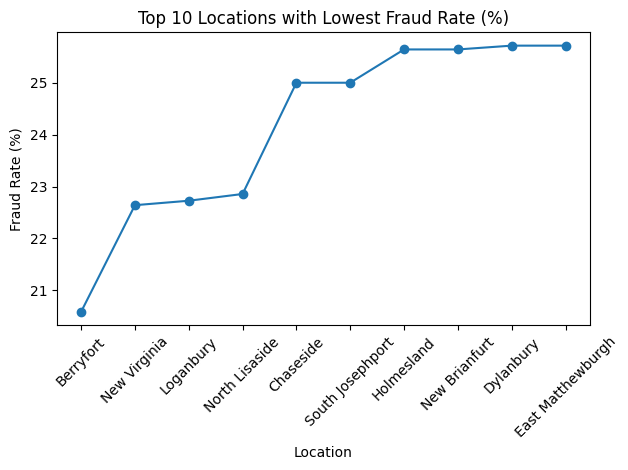

In [20]:


# Group by location
grouped = df.groupby("location")["is_fraud"].agg(["mean", "count"])

# Keep locations with enough transactions (important for reliability)
grouped = grouped[grouped["count"] >= 30]

# Sort by lowest fraud rate
sorted_data = grouped.sort_values("mean", ascending=True)

# Select bottom 10 locations
bottom10 = sorted_data.head(10)

# Convert to percentage
fraud_percent = bottom10["mean"] * 100

# Plot
plt.figure()
plt.plot(bottom10.index, fraud_percent, marker='o')

plt.title("Top 10 Locations with Lowest Fraud Rate (%)")
plt.xlabel("Location")
plt.ylabel("Fraud Rate (%)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


### Device Type Characteristics 

### The Most Affected Devices 

In [21]:


# # Calculate fraud rate per device
# device_fraud = df.groupby("device_type")["is_fraud"].mean() * 100

# # Sort from highest to lowest
# device_fraud = device_fraud.sort_values(ascending=False)

# # Plot
# plt.figure()
# plt.plot(device_fraud.index, device_fraud.values, marker='o')

# plt.title("Fraud Rate by Device Type (%)")
# plt.xlabel("Device Type")
# plt.ylabel("Fraud Rate (%)")

# plt.tight_layout()
# plt.show()


### IsFraud(target variable) Characteristics 

### Age Characteristics 

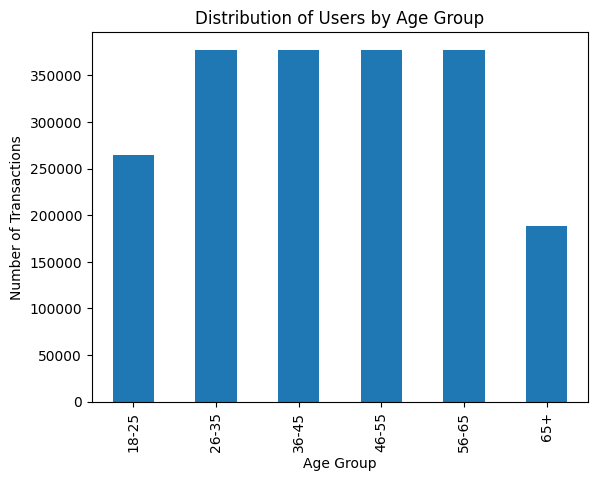

In [22]:


# Create age groups
bins = [18, 25, 35, 45, 55, 65, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]

df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

# Plot
plt.figure()

df["age_group"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribution of Users by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")

plt.show()






### the most age range affected by fraud 

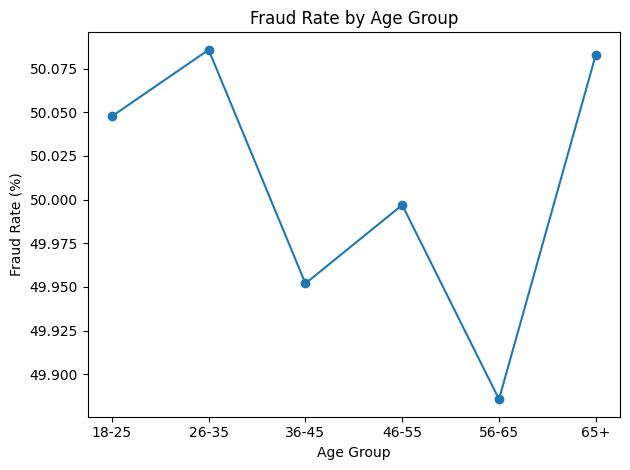

In [23]:



# Clean column names
df.columns = df.columns.str.strip()

# Detect fraud column
fraud_col = None
for col in df.columns:
    if col.lower() in ["is_fraud", "isfraud"]:
        fraud_col = col
        break

# Create ordered age groups
bins = [18, 26, 36, 46, 56, 66, 120]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

# Calculate fraud rate by age group
age_fraud = df.groupby("age_group")[fraud_col].mean() * 100
age_fraud = age_fraud.reindex(labels)

# Plot
plt.figure()
plt.plot(age_fraud.index, age_fraud.values, marker='o')
plt.xlabel("Age Group")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Age Group")
plt.tight_layout()
plt.show()


### Transaction Timing per Age

In [24]:
df[['age', 'amount']].corr()

,age,amount
age,1.000000,-0.000563
amount,-0.000563,1.000000


### Income Characteristics 

### Fraud Rate Per Income 

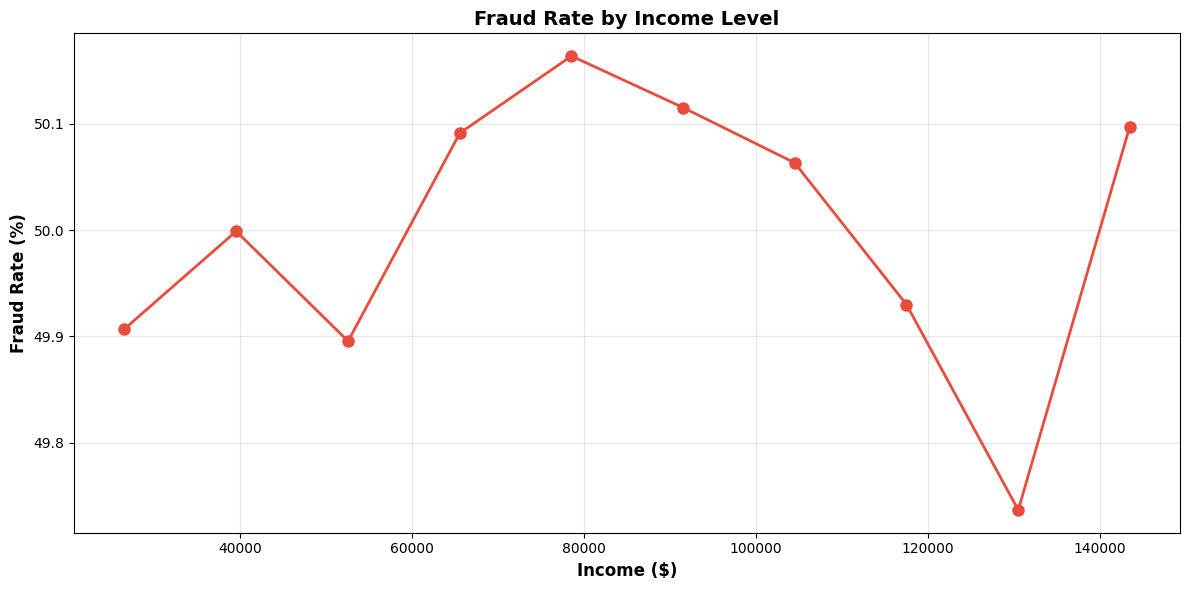

Fraud Rate by Income Bracket:
                          fraud_rate
income                              
(20000.089, 32995.098]       49.9070
(32995.098, 46014.172]       49.9990
(46014.172, 59048.364]       49.8955
(59048.364, 72042.05]        50.0915
(72042.05, 85032.87]         50.1640
(85032.87, 97998.086]        50.1155
(97998.086, 111009.909]      50.0635
(111009.909, 124046.366]     49.9300
(124046.366, 137031.813]     49.7365
(137031.813, 149999.96]      50.0975


In [25]:





# Create income bins
income_bins = pd.qcut(df['income'], q=10, duplicates='drop')

# Calculate fraud rate per income bin
fraud_rate_by_income = df.groupby(income_bins)['is_fraud'].agg(['sum', 'count'])
fraud_rate_by_income['fraud_rate'] = (fraud_rate_by_income['sum'] / fraud_rate_by_income['count']) * 100

# Get the midpoint of each income bin for plotting
income_midpoints = [interval.mid for interval in fraud_rate_by_income.index]

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(income_midpoints, fraud_rate_by_income['fraud_rate'].values, marker='o', linewidth=2, markersize=8, color='#e74c3c')
plt.xlabel('Income ($)', fontsize=12, fontweight='bold')
plt.ylabel('Fraud Rate (%)', fontsize=12, fontweight='bold')
plt.title('Fraud Rate by Income Level', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fraud_rate_by_income.png', dpi=300, bbox_inches='tight')
plt.show()

print('Fraud Rate by Income Bracket:')
print(fraud_rate_by_income[['fraud_rate']])

### Debt Characterisitcs 

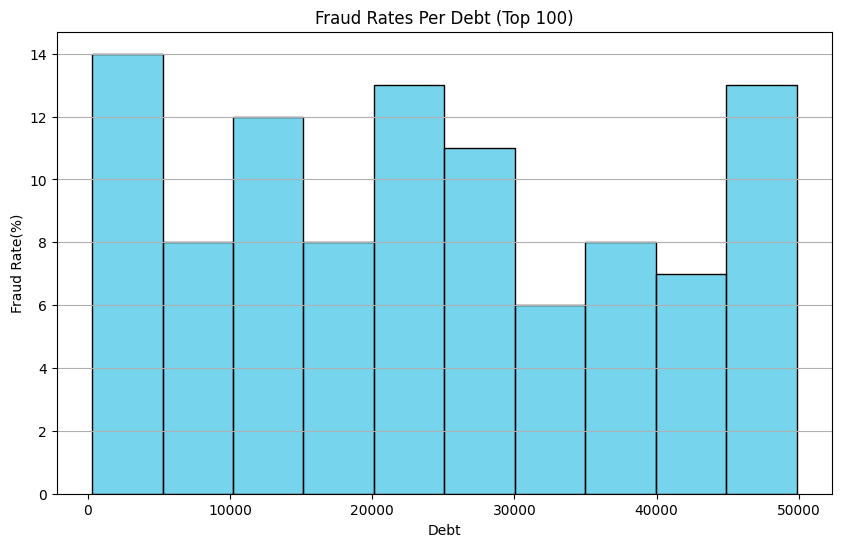

In [26]:
# Filtrer seulement les fraudes
df_fraud = df[df['is_fraud']==1]

# Prendre un échantillon top 100 pour lisibilité
df_sample = df_fraud['debt'].sample(100, random_state=42)

# Calculer histogramme et convertir en pourcentage
counts, bins = np.histogram(df_sample, bins=10)
percentages = (counts / counts.sum()) * 100  # pourcentage

# Graphe
plt.figure(figsize=(10,6))
plt.bar(bins[:-1], percentages, width=np.diff(bins), color="#1BB9E099", edgecolor='black', align='edge')
plt.title("Fraud Rates Per Debt (Top 100)")
plt.xlabel("Debt")
plt.ylabel("Fraud Rate(%)")
plt.grid(axis='y')
plt.show()

### Credit Score Characteristics 

### Fraud Rate by credit_score 

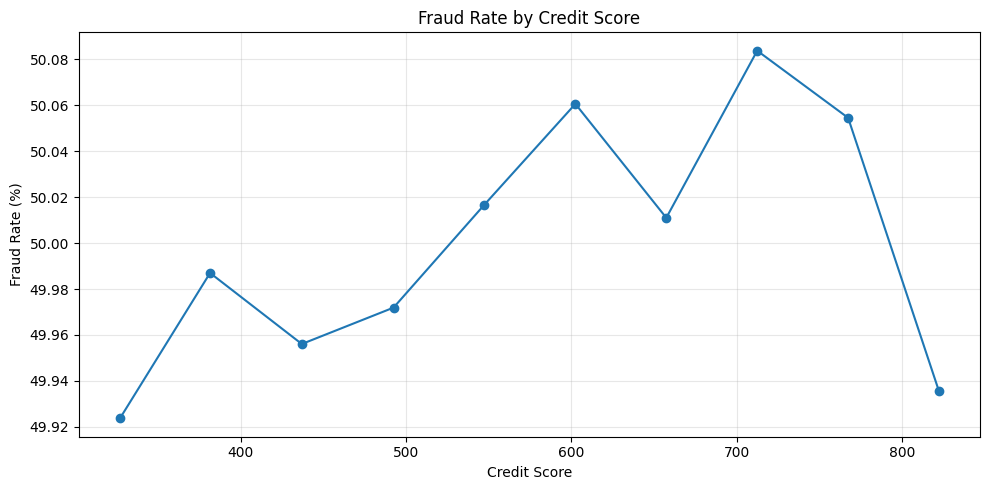

Saved fraud_by_credit_score.png
                  fraud_rate
credit_score                
(299.999, 354.0]   49.923664
(354.0, 409.0]     49.986995
(409.0, 465.0]     49.956050
(465.0, 520.0]     49.971904
(520.0, 575.0]     50.016776
(575.0, 630.0]     50.060652
(630.0, 685.0]     50.011024
(685.0, 740.0]     50.083820
(740.0, 795.0]     50.054577
(795.0, 850.0]     49.935386


In [28]:
try:
    df
except NameError:
    df = pd.read_csv('fraud_detection_dataset.csv')

credit_bins = pd.qcut(df['credit_score'], q=10, duplicates='drop')
credit_agg = df.groupby(credit_bins)['is_fraud'].agg(['sum','count'])
credit_agg['fraud_rate'] = credit_agg['sum']/credit_agg['count']*100
credit_mid = [interval.mid for interval in credit_agg.index]
plt.figure(figsize=(10,5))
plt.plot(credit_mid, credit_agg['fraud_rate'].values, marker='o', color='tab:blue')
plt.xlabel('Credit Score')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Credit Score')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fraud_by_credit_score.png', dpi=300, bbox_inches='tight')
plt.show()

print('Saved fraud_by_credit_score.png')
print(credit_agg[['fraud_rate']])

### 2.4 Data Check 

##### 2.4.1 Check Nulls 

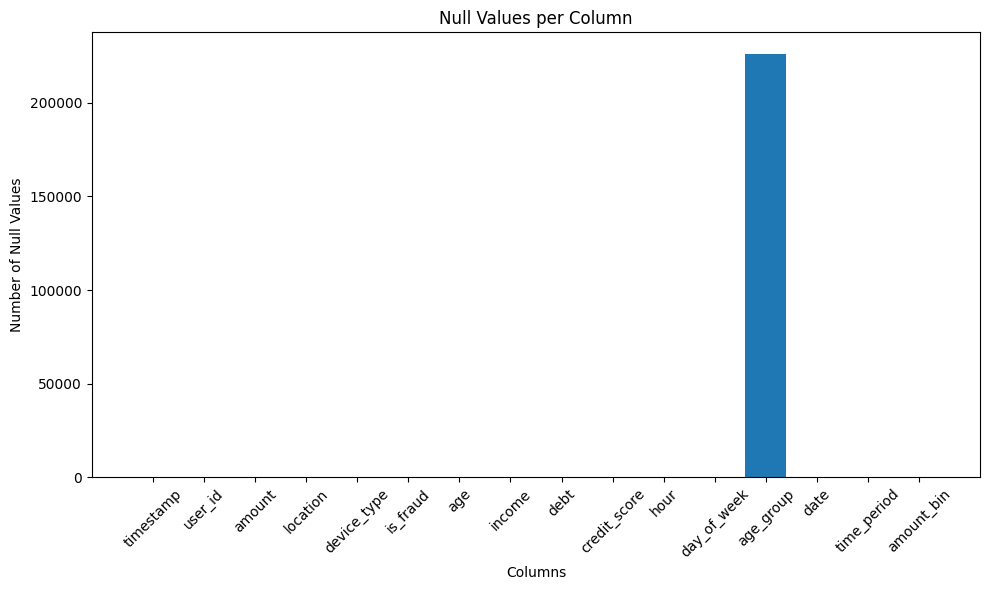

In [29]:
bins = [18, 25, 35, 45, 55, 65]
labels = ["18-24", "25-34", "35-44", "45-54", "55-64"]

# Create age_group
df["age_group"] = pd.cut(df["age"], bins=bins)

# Count nulls created by binning
# Count null values in each column (including age_group)
null_counts = df.isnull().sum()

# Plot
plt.figure(figsize=(10,6))
plt.bar(null_counts.index, null_counts.values)

plt.xlabel("Columns")
plt.ylabel("Number of Null Values")
plt.title("Null Values per Column")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.4.2 Duplicates

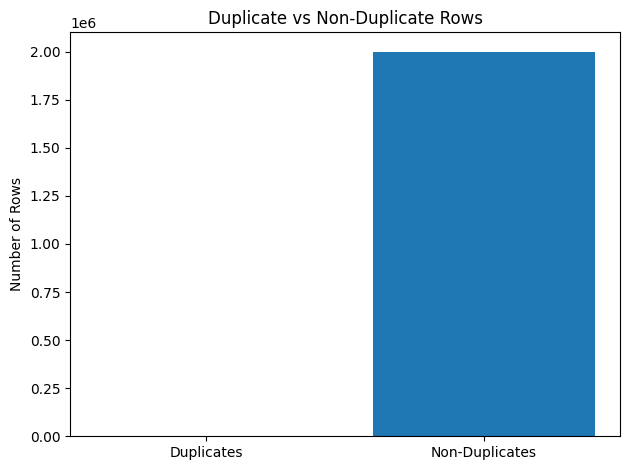

In [30]:
# Count duplicates
duplicate_count = df.duplicated().sum()

# Count non-duplicates
non_duplicate_count = len(df) - duplicate_count

# Plot
plt.figure()
plt.bar(["Duplicates", "Non-Duplicates"],
        [duplicate_count, non_duplicate_count])

plt.title("Duplicate vs Non-Duplicate Rows")
plt.ylabel("Number of Rows")

plt.tight_layout()
plt.show()

# 3. Data Preparation 

#####  Missing Values Analysis

In [31]:
# Define age intervals
bins = [0, 25, 35, 45, 55, 65, 75, 100]
labels = ['0-25', '26-35', '36-45', '46-55', '56-65', '66-75', '76+']

# Create age_group column
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)
print(df['age'].min())
print(df['age'].max())
bins = [18, 25, 35, 45, 55, 65, 75]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels, 
    include_lowest=True
)
print(df['age_group'].isnull().sum())

18
70
0


### 3.2 Data Analysis

###### 3.2.1 After Cleaning Age Column

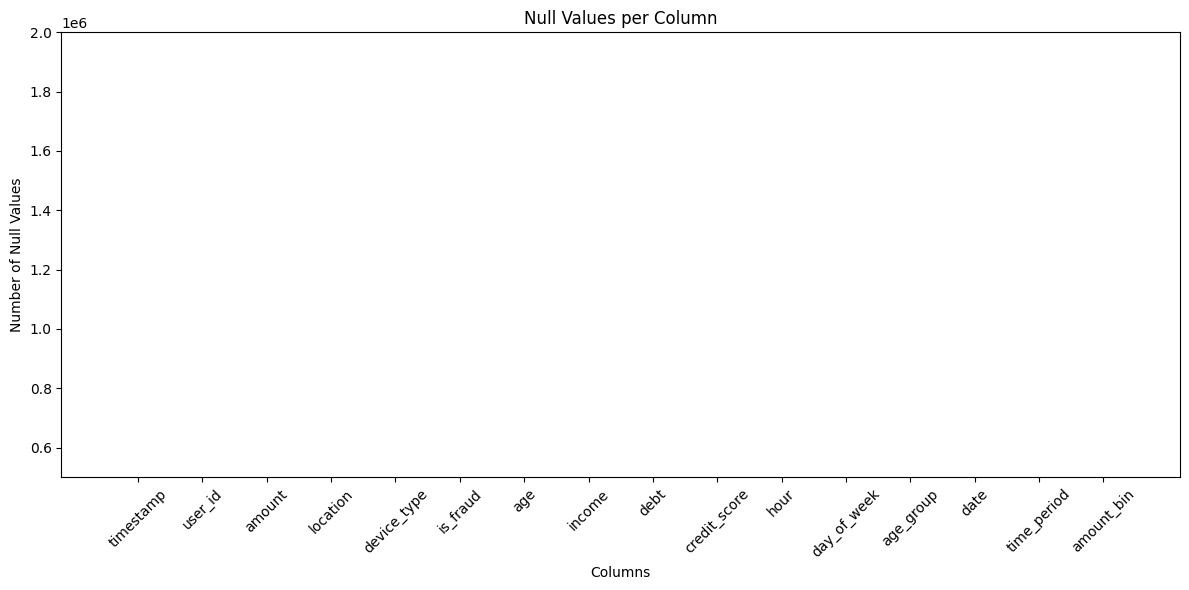

In [32]:
# Create age_group with your bins
bins = [18, 25, 35, 45, 55, 65, 75]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65', '66-75']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Count null values
null_counts = df.isnull().sum()

# Plot
plt.figure(figsize=(12,6))
plt.bar(null_counts.index, null_counts.values)

plt.title("Null Values per Column")
plt.xlabel("Columns")
plt.ylabel("Number of Null Values")
plt.xticks(rotation=45)

# 🔹 Set Y-axis range
plt.ylim(500000, 2000000)

plt.tight_layout()
plt.show()

### 3.2.2 Preprocessing 

In [146]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Extract time features
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day

In [147]:
numerical_cols = [
    'amount',
    'age',
    'income',
    'debt',
    'credit_score'
]

###### Encoding 

In [148]:
# Step 1 — Extract time features FIRST before dropping timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')
df['hour']  = df['timestamp'].dt.hour
df['day']   = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month
df['year']  = df['timestamp'].dt.year

# Step 2 — NOW drop unnecessary columns
df = df.drop(columns=[
    'date', 'age_group', 'time_period', 'amount_bin',
    'user_id', 'timestamp', 'day_of_week'
], errors='ignore')

# Step 3 — Encode categoricals
cat_cols = ['location', 'device_type']
le_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    le_encoders[col] = le  # save each encoder separately

# Step 4 — Get sizes AFTER encoding
num_locations = df['location'].nunique()
num_devices   = df['device_type'].nunique()

# Step 5 — Define columns
num_cols = ['amount','age','income','debt','credit_score',
            'hour','day','month','year']
cat_cols = ['location','device_type']
num_numeric = len(num_cols)

print("num_locations:", num_locations)
print("num_devices:",   num_devices)
print("num_numeric:",   num_numeric)
print("Remaining string cols:", 
      df.select_dtypes(include='str').columns.tolist())
print(df.dtypes)

num_locations: 104592
num_devices: 3
num_numeric: 9
Remaining string cols: []
amount          float64
location          int32
device_type       int32
is_fraud          int64
age               int64
income          float64
debt            float64
credit_score      int64
year              int32
month             int32
day               int32
hour              int32
dtype: object


In [36]:
print(df.dtypes)

amount          float64
location          int32
device_type       int32
is_fraud          int64
age               int64
income          float64
debt            float64
credit_score      int64
hour              int32
year              int32
month             int32
day               int32
dtype: object


###### Numercial Columns Exctraction 

In [119]:
numerical_cols = [
    'amount',
    'age',
    'income',
    'debt',
    'credit_score'
]

In [38]:
# Check BEFORE scaling
print(df[['day', 'month', 'year']].nunique())
print(df[['day', 'month', 'year']].describe())

day      31
month    12
year      2
dtype: int64
                day         month          year
count  2.000000e+06  2.000000e+06  2.000000e+06
mean   1.577902e+01  6.518742e+00  2.023164e+03
std    8.793523e+00  3.450187e+00  3.704629e-01
min    1.000000e+00  1.000000e+00  2.023000e+03
25%    8.000000e+00  4.000000e+00  2.023000e+03
50%    1.600000e+01  7.000000e+00  2.023000e+03
75%    2.300000e+01  1.000000e+01  2.023000e+03
max    3.100000e+01  1.200000e+01  2.024000e+03


In [39]:
# Make sure this line runs BEFORE scaling
df.drop(columns=['day_of_week'], inplace=True, errors='ignore')

# Also drop any other string columns that sneak in
# Check for object dtype columns
print(df.select_dtypes(include='object').columns.tolist())

[]


In [149]:
scaler = MinMaxScaler()
numerical_focused = [col for col in df.columns if col not in cat_cols + ['is_fraud']]
df[numerical_focused] = scaler.fit_transform(df[numerical_focused])

In [150]:
df[numerical_cols].describe()

,amount,age,income,debt,credit_score
count,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06,2.000000e+06
mean,3.490348e-01,5.000827e-01,5.001612e-01,4.996807e-01,4.996102e-01
std,3.014355e-01,2.941835e-01,2.887080e-01,2.888013e-01,2.893164e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.906633e-02,2.500000e-01,2.502348e-01,2.493098e-01,2.490909e-01
50%,1.983982e-01,5.000000e-01,5.002527e-01,4.996185e-01,5.000000e-01
75%,5.985403e-01,7.500000e-01,7.502882e-01,7.496059e-01,7.509091e-01
max,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [42]:
print("numerical_focused:", numerical_focused)
print("\nSample after scaling:")
print(df[numerical_focused].head(3))
print("\nMin values:\n", df[numerical_focused].min())
print("Max values:\n", df[numerical_focused].max())

numerical_focused: ['amount', 'age', 'income', 'debt', 'credit_score', 'hour', 'year', 'month', 'day']

Sample after scaling:
     amount       age    income      debt  credit_score      hour  year  \
0  0.198195  0.730769  0.173269  0.167880      0.645455  0.086957   0.0   
1  0.046371  0.653846  0.383723  0.568681      0.172727  0.478261   0.0   
2  0.165616  0.769231  0.822720  0.782436      0.356364  0.217391   0.0   

      month       day  
0  1.000000  0.466667  
1  0.818182  0.966667  
2  0.909091  0.666667  

Min values:
 amount          0.0
age             0.0
income          0.0
debt            0.0
credit_score    0.0
hour            0.0
year            0.0
month           0.0
day             0.0
dtype: float64
Max values:
 amount          1.0
age             1.0
income          1.0
debt            1.0
credit_score    1.0
hour            1.0
year            1.0
month           1.0
day             1.0
dtype: float64


###### Splitting 

In [151]:
# ======================================
# TRAIN / TEST SPLIT (80% / 20%)
# ======================================



# Separate features and target
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Perform stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 20% test
    random_state=42,    # reproducibility
    stratify=y          # keeps fraud ratio consistent
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nFraud distribution in training set:")
print(y_train.value_counts(normalize=True))

print("\nFraud distribution in test set:")
print(y_test.value_counts(normalize=True))

Training set shape: (1600000, 11)
Test set shape: (400000, 11)

Fraud distribution in training set:
is_fraud
0    0.5
1    0.5
Name: proportion, dtype: float64

Fraud distribution in test set:
is_fraud
0    0.5
1    0.5
Name: proportion, dtype: float64


In [44]:
print(X_train.dtypes)

amount          float64
location          int32
device_type       int32
age             float64
income          float64
debt            float64
credit_score    float64
hour            float64
year            float64
month           float64
day             float64
dtype: object


In [45]:
print('is_fraud' in df.columns)        # should be True
print(df['is_fraud'].value_counts())   # should show 1M / 1M

True
is_fraud
0    1000000
1    1000000
Name: count, dtype: int64


### 4. Training 

In [152]:
num_cols = ['amount', 'age', 'income', 'debt', 'credit_score', 'hour', 'day', 'month', 'year']

# Rebuild tensors
X_train_num_pt = torch.tensor(X_train[num_cols].values, dtype=torch.float32)
X_test_num_pt = torch.tensor(X_test[num_cols].values, dtype=torch.float32)
X_train_cat_pt = torch.tensor(X_train[cat_cols].values, dtype=torch.long)
X_test_cat_pt = torch.tensor(X_test[cat_cols].values, dtype=torch.long)
y_train_pt = torch.tensor(y_train.values, dtype=torch.float32)
y_test_pt = torch.tensor(y_test.values, dtype=torch.float32)

train_dataset = TensorDataset(X_train_num_pt, X_train_cat_pt, y_train_pt)
train_loader = DataLoader(train_dataset, batch_size=8192, shuffle=True)
test_dataset = TensorDataset(X_test_num_pt, X_test_cat_pt, y_test_pt)
test_loader = DataLoader(test_dataset, batch_size=8192, shuffle=False)

###### Convert to PyTorch Tensors 

In [104]:

X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)
print("Tensor conversion done ✅")

Tensor conversion done ✅


###### Dataloaders Creation 

###### Model Definition 

In [159]:
class FTTransformer(nn.Module):
    def __init__(self, num_numeric, num_locations, num_devices, embed_dim=8):
        super(FTTransformer, self).__init__()

        self.location_emb = nn.Embedding(num_locations, embed_dim)
        self.device_emb = nn.Embedding(num_devices, embed_dim)

        input_dim = num_numeric + embed_dim + embed_dim  # 9 + 8 + 8 = 25

        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  # No Sigmoid
        )

    def forward(self, x_num, x_cat):
        loc_emb = self.location_emb(x_cat[:, 0].long())
        dev_emb = self.device_emb(x_cat[:, 1].long())
        x = torch.cat((x_num, loc_emb, dev_emb), dim=1)
        return self.model(x)

num_numeric = 9
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FTTransformer(
    num_numeric=num_numeric,
    num_locations=num_locations,
    num_devices=num_devices,
    embed_dim=8
).to(device)



###### Model Initialization 

In [160]:
model = FTTransformer(
    num_numeric=9,
    num_locations=num_locations,
    num_devices=num_devices,
    embed_dim=8
).to(device)




###### Loss function Definition

In [161]:
criterion = nn.BCEWithLogitsLoss()

###### Optimizer Definition 

In [162]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

###### Training Loop 

In [163]:
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for i, (X_num_batch, X_cat_batch, y_batch) in enumerate(train_loader):
        X_num_batch = X_num_batch.to(device)
        X_cat_batch = X_cat_batch.to(device)
        y_batch = y_batch.to(device).float().view(-1, 1)

        optimizer.zero_grad()
        outputs = model(X_num_batch, X_cat_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"✓ Epoch {epoch+1}/{epochs} - Avg Loss: {avg_loss:.4f}")

✓ Epoch 1/3 - Avg Loss: 0.5474
✓ Epoch 2/3 - Avg Loss: 0.1878
✓ Epoch 3/3 - Avg Loss: 0.0804


###### Accuracy 

In [164]:
model.eval()

y_pred_list = []
y_true_list = []

with torch.no_grad():

    for X_num_batch, X_cat_batch, y_batch in test_loader:

        X_num_batch = X_num_batch.to(device)
        X_cat_batch = X_cat_batch.to(device)

        outputs = model(X_num_batch, X_cat_batch)

        preds = (outputs > 0.5).float()

        y_pred_list.append(preds.cpu())
        y_true_list.append(y_batch.cpu())

# concatenate batches
y_pred_np = torch.cat(y_pred_list).numpy().flatten()
y_test_np = torch.cat(y_true_list).numpy().flatten()

print("Prediction step completed ✅")



Prediction step completed ✅


In [165]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_num_batch, X_cat_batch, y_batch in test_loader:
        X_num_batch = X_num_batch.to(device)
        X_cat_batch = X_cat_batch.to(device)
        
        outputs = torch.sigmoid(model(X_num_batch, X_cat_batch))
        
        preds = (outputs >= 0.35).float()
        
    all_preds.extend(preds.cpu().numpy().flatten())
all_labels.extend(y_batch.numpy().flatten())

print("TRAIN SET:")
print(classification_report(all_labels, all_preds))

TRAIN SET:
              precision    recall  f1-score   support

         0.0       0.98      0.98      0.98      3366
         1.0       0.98      0.98      0.98      3418

    accuracy                           0.98      6784
   macro avg       0.98      0.98      0.98      6784
weighted avg       0.98      0.98      0.98      6784



In [166]:
with open('fttransformer.pkl', 'wb') as f:
    pickle.dump({'model': model, 'scaler': scaler}, f)

with open('fttransformer.pkl', 'rb') as f:
    check = pickle.load(f)
print("Saved!")
print("First layer:", list(check['model'].parameters())[0].shape)  # must be [128, 25]
print("Scaler max:", check['scaler'].data_max_[:3])

Saved!
First layer: torch.Size([104592, 8])
Scaler max: [4.9999900e+03 7.0000000e+01 1.4999996e+05]


In [168]:
with open('fttransformer.pkl', 'rb') as f:
    check = pickle.load(f)
print("Scaler feature names:", check['scaler'].feature_names_in_)

Scaler feature names: ['amount' 'age' 'income' 'debt' 'credit_score' 'year' 'month' 'day' 'hour']


In [55]:
model.eval()
with torch.no_grad():
    for X_num_batch, X_cat_batch, y_batch in train_loader:
        X_num_batch = X_num_batch.to(device)
        X_cat_batch = X_cat_batch.to(device)
        outputs = torch.sigmoid(model(X_num_batch, X_cat_batch))
        print("Output min:", outputs.min().item())
        print("Output max:", outputs.max().item())
        print("Output mean:", outputs.mean().item())
        print("Sample outputs:", outputs[:10].squeeze().tolist())
        print("Sample labels:", y_batch[:10].tolist())
        break

Output min: 1.5756439097458497e-05
Output max: 0.9995520710945129
Output mean: 0.4898398518562317
Sample outputs: [0.9868424534797668, 0.0015511269448325038, 0.38330337405204773, 0.1061631590127945, 0.9905431866645813, 0.9782911539077759, 0.9820706844329834, 0.0002591807278804481, 0.0023418052587658167, 0.9521166086196899]
Sample labels: [1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0]


In [56]:


print(confusion_matrix(y_test_np, y_pred_np))

[[199381    619]
 [  7954 192046]]


In [57]:


print("Predictions distribution:")
print(np.unique(all_preds, return_counts=True))

print("Labels distribution:")
print(np.unique(all_labels, return_counts=True))

Predictions distribution:
(array([0., 1.], dtype=float32), array([3317, 3467], dtype=int64))
Labels distribution:
(array([0., 1.], dtype=float32), array([3366, 3418], dtype=int64))


In [58]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(all_labels, all_preds)
print("ROC AUC:", auc)

ROC AUC: 0.978274727448651


              precision    recall  f1-score   support

  Legitimate       0.99      0.97      0.98      3366
       Fraud       0.97      0.99      0.98      3418

    accuracy                           0.98      6784
   macro avg       0.98      0.98      0.98      6784
weighted avg       0.98      0.98      0.98      6784



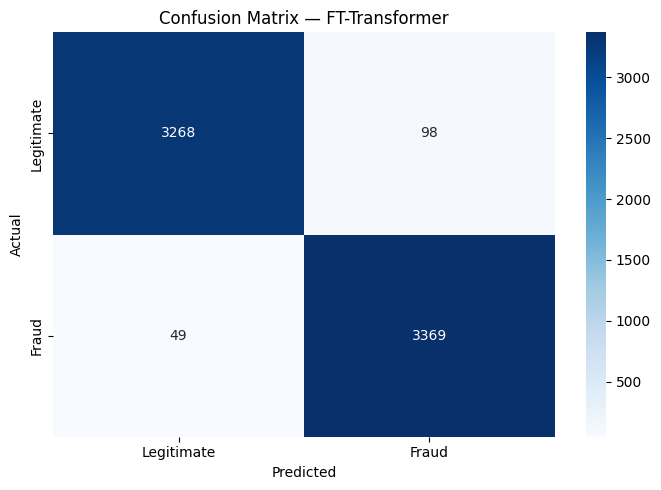

In [59]:
# Classification report
print(classification_report(all_labels, all_preds, 
      target_names=['Legitimate', 'Fraud']))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'])
plt.title('Confusion Matrix — FT-Transformer')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [158]:
for X_num_b, X_cat_b, y_b in train_loader:
    print("X_num shape:", X_num_b.shape)
    break

X_num shape: torch.Size([8192, 9])


#### 4.2.2 Features Extraction

In [61]:
numeric_focused = [
    'amount',
    'age',
    'income',
    'debt',
    'credit_score',
    'hour',
    'day',
    'month',
    'years'
]

In [154]:
df_raw = pd.read_csv(r"C:\pfe\fraud_detection_dataset.csv")

df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], errors='coerce')
df_raw['hour']  = df_raw['timestamp'].dt.hour
df_raw['day']   = df_raw['timestamp'].dt.day
df_raw['month'] = df_raw['timestamp'].dt.month
df_raw['year']  = df_raw['timestamp'].dt.year

df_raw = df_raw.drop(columns=['user_id', 'timestamp', 'location', 'device_type'], errors='ignore')

df_raw['debt_to_income']   = df_raw['debt']   / (df_raw['income'] + 1e-6)
df_raw['amount_to_income'] = df_raw['amount'] / (df_raw['income'] + 1e-6)
df_raw['amount_to_debt']   = df_raw['amount'] / (df_raw['debt']   + 1e-6)
df_raw['credit_x_amount']  = df_raw['credit_score'] * df_raw['amount']
df_raw['age_x_debt']       = df_raw['age'] * df_raw['debt']

print("Columns:", df_raw.columns.tolist())
print("Amount max:", df_raw['amount'].max())

Columns: ['amount', 'is_fraud', 'age', 'income', 'debt', 'credit_score', 'hour', 'day', 'month', 'year', 'debt_to_income', 'amount_to_income', 'amount_to_debt', 'credit_x_amount', 'age_x_debt']
Amount max: 4999.99


In [155]:
df_raw['debt_to_income']   = df_raw['debt']   / (df_raw['income'] + 1e-6)
df_raw['amount_to_income'] = df_raw['amount'] / (df_raw['income'] + 1e-6)
df_raw['amount_to_debt']   = df_raw['amount'] / (df_raw['debt']   + 1e-6)
df_raw['credit_x_amount']  = df_raw['credit_score'] * df_raw['amount']
df_raw['age_x_debt']       = df_raw['age'] * df_raw['debt']
print("Done!")

Done!


###### Add fetures to df 

###### Numerical cols 

###### split and scale

In [156]:
num_cols_9  = ['amount','age','income','debt','credit_score','hour','day','month','year']
num_cols_14 = num_cols_9 + ['debt_to_income','amount_to_income','amount_to_debt','credit_x_amount','age_x_debt']

X_raw = df_raw.drop(columns=['is_fraud'])
y_raw = df_raw['is_fraud']
X_train_raw, _, _, _ = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42, stratify=y_raw)

scaler_fresh_9  = MinMaxScaler()
scaler_fresh_9.fit(X_train_raw[num_cols_9])

scaler_fresh_14 = MinMaxScaler()
scaler_fresh_14.fit(X_train_raw[num_cols_14])

print("9-feature scaler max:", scaler_fresh_9.data_max_[:3])
print("14-feature scaler max:", scaler_fresh_14.data_max_[:3])
# Should be like [4999, 70, 149999]

9-feature scaler max: [4.9999900e+03 7.0000000e+01 1.4999996e+05]
14-feature scaler max: [4.9999900e+03 7.0000000e+01 1.4999996e+05]


In [157]:
# Split from df_raw directly
X_raw = df_raw.drop(columns=['is_fraud'])
y_raw = df_raw['is_fraud']

print("Amount max in X_raw:", X_raw['amount'].max())  # should be ~4999

Amount max in X_raw: 4999.99


###### Tensor Conversion And Dataloaders 

In [64]:
X_train_num_pt = torch.tensor(X_train[num_cols].values, dtype=torch.float32)
X_test_num_pt  = torch.tensor(X_test[num_cols].values,  dtype=torch.float32)
X_train_cat_pt = torch.tensor(X_train[cat_cols].values, dtype=torch.long)
X_test_cat_pt  = torch.tensor(X_test[cat_cols].values,  dtype=torch.long)
y_train_pt     = torch.tensor(y_train.values, dtype=torch.float32)
y_test_pt      = torch.tensor(y_test.values,  dtype=torch.float32)

train_dataset = TensorDataset(X_train_num_pt, X_train_cat_pt, y_train_pt)
test_dataset  = TensorDataset(X_test_num_pt,  X_test_cat_pt,  y_test_pt)
train_loader  = DataLoader(train_dataset, batch_size=8192, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=8192, shuffle=False)
print("Done!")

Done!


###### Model Definition And Initialization 

In [65]:
class FTTransformer(nn.Module):
    def __init__(self, num_numeric, num_locations, num_devices, embed_dim=8):
        super(FTTransformer, self).__init__()
        self.location_emb = nn.Embedding(num_locations, embed_dim)
        self.device_emb   = nn.Embedding(num_devices,   embed_dim)
        input_dim = num_numeric + embed_dim + embed_dim

        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.BatchNorm1d(16),
            nn.Dropout(0.18),
            nn.Linear(16, 1)
        )

    def forward(self, x_num, x_cat):
        loc_emb = self.location_emb(x_cat[:, 0].long())
        dev_emb = self.device_emb(x_cat[:, 1].long())
        x = torch.cat((x_num, loc_emb, dev_emb), dim=1)
        return self.model(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FTTransformer(
    num_numeric=num_numeric,
    num_locations=num_locations,
    num_devices=num_devices,
    embed_dim=8
).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
print("Model ready")

Model ready


###### Criterion 

###### Training Loop 

In [66]:
epochs = 3

for epoch in range(epochs):

    # Training
    model.train()
    total_loss = 0

    for i, (X_num_batch, X_cat_batch, y_batch) in enumerate(train_loader):

        X_num_batch = X_num_batch.to(device)
        X_cat_batch = X_cat_batch.to(device)
        y_batch = y_batch.to(device).float().view(-1, 1)

        optimizer.zero_grad()

        outputs = model(X_num_batch, X_cat_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)


    # Validation accuracy each epoch
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():

        for X_num_batch, X_cat_batch, y_batch in test_loader:

            X_num_batch = X_num_batch.to(device)
            X_cat_batch = X_cat_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_num_batch, X_cat_batch)

            preds = (outputs >= 0.5).float().squeeze()

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    val_acc = correct / total

    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/3 | Loss: 0.7246 | Val Acc: 0.5199
Epoch 2/3 | Loss: 0.6183 | Val Acc: 0.6928
Epoch 3/3 | Loss: 0.4502 | Val Acc: 0.8468


###### Model Evaluation 

In [67]:
model.eval()

y_pred_list = []
y_true_list = []

with torch.no_grad():

    for X_num_batch, X_cat_batch, y_batch in test_loader:

        X_num_batch = X_num_batch.to(device)
        X_cat_batch = X_cat_batch.to(device)

        outputs = model(X_num_batch, X_cat_batch)

        preds = (outputs > 0.65).float()

        y_pred_list.append(preds.cpu())
        y_true_list.append(y_batch.cpu())

# concatenate batches
y_pred_np = torch.cat(y_pred_list).numpy().flatten()
y_test_np = torch.cat(y_true_list).numpy().flatten()

print("Prediction step completed ✅")



Prediction step completed ✅


###### Classification Report 

In [68]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_num_batch, X_cat_batch, y_batch in test_loader:
        X_num_batch = X_num_batch.to(device)
        X_cat_batch = X_cat_batch.to(device)
        
        outputs = torch.sigmoid(model(X_num_batch, X_cat_batch))
        
        preds = (outputs >= 0.35).float()
        
    all_preds.extend(preds.cpu().numpy().flatten())
all_labels.extend(y_batch.numpy().flatten())

print("TRAIN SET:")
print(classification_report(all_labels, all_preds))

TRAIN SET:
              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95      3366
         1.0       0.95      0.95      0.95      3418

    accuracy                           0.95      6784
   macro avg       0.95      0.95      0.95      6784
weighted avg       0.95      0.95      0.95      6784



###### Confusion Matrix 

In [69]:

print(confusion_matrix(y_test_np, y_pred_np))

[[199993      7]
 [ 68635 131365]]


###### roc_auc score

In [70]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(all_labels, all_preds)
print("ROC AUC:", auc)

ROC AUC: 0.9475159817637359


###### Saved in a pickle 

In [95]:
ft_extracted_bundle = {
    'model': model,
    'scaler': scaler
}
with open('fttransformer_extracted.pkl', 'wb') as f:
    pickle.dump(ft_extracted_bundle, f)
print("FTTransformer extracted saved!")

FTTransformer extracted saved!


###  5. Training (MLP Model)

###### Build tensors (all features in one tensor):

In [72]:
all_cols = ['amount', 'age', 'income', 'debt', 'credit_score',
            'hour', 'day', 'month', 'year']

X_train_mlp = X_train[all_cols].copy()
X_test_mlp  = X_test[all_cols].copy()

# Scale everything including location and device_type
scaler_mlp = MinMaxScaler()
X_train_mlp[all_cols] = scaler_mlp.fit_transform(X_train_mlp[all_cols])
X_test_mlp[all_cols]  = scaler_mlp.transform(X_test_mlp[all_cols])

  # should be 1.0
print("Max amount:",   X_train_mlp['amount'].max())    # should be 1.0

# Rebuild tensors
X_train_pt = torch.tensor(X_train_mlp.values, dtype=torch.float32)
X_test_pt  = torch.tensor(X_test_mlp.values,  dtype=torch.float32)
y_train_pt = torch.tensor(y_train.values, dtype=torch.float32)
y_test_pt  = torch.tensor(y_test.values,  dtype=torch.float32)

# Rebuild dataloaders
train_dataset_mlp = TensorDataset(X_train_pt, y_train_pt)
test_dataset_mlp  = TensorDataset(X_test_pt,  y_test_pt)
train_loader_mlp  = DataLoader(train_dataset_mlp, batch_size=8192, shuffle=True)
test_loader_mlp   = DataLoader(test_dataset_mlp,  batch_size=8192, shuffle=False)

Max amount: 1.0


###### Dataloaders

###### MLP definition 

In [73]:
class MLP(nn.Module):
    def __init__(self, input_dim):
        super(MLP, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.4),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.4),

            nn.Linear(32, 1)  # No Sigmoid
        )

    def forward(self, x):
        return self.model(x)

In [74]:
input_dim = len(all_cols)
print("input_dim:", input_dim)

mlp_model = MLP(input_dim=input_dim).to(device)
criterion  = nn.BCEWithLogitsLoss()
optimizer  = torch.optim.Adam(mlp_model.parameters(), lr=3e-4)

input_dim: 9


###### MLP Training Loop 

In [75]:
epochs = 3

for epoch in range(epochs):

    # Training
    mlp_model.train()
    total_loss = 0

    for i, (X_batch, y_batch) in enumerate(train_loader_mlp):  # ← 1 input
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).float().view(-1, 1)

        optimizer.zero_grad()
        outputs = mlp_model(X_batch)  # ← mlp_model, 1 input
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader_mlp)

    # Validation accuracy each epoch
    mlp_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader_mlp:  # ← 1 input
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = torch.sigmoid(mlp_model(X_batch))  # ← mlp_model
            preds = (outputs >= 0.5).float().squeeze()

            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avg_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch 1/3 | Loss: 0.4215 | Val Acc: 0.9526
Epoch 2/3 | Loss: 0.1769 | Val Acc: 0.9755
Epoch 3/3 | Loss: 0.1065 | Val Acc: 0.9824


In [76]:


print("Predictions distribution:")
print(np.unique(all_preds, return_counts=True))

print("Labels distribution:")
print(np.unique(all_labels, return_counts=True))

Predictions distribution:
(array([0., 1.], dtype=float32), array([3362, 3422], dtype=int64))
Labels distribution:
(array([0., 1.], dtype=float32), array([3366, 3418], dtype=int64))


###### MLP Evaluation 

In [77]:
mlp_model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_mlp:  # ← 1 input only
        X_batch = X_batch.to(device)
        
        outputs = torch.sigmoid(mlp_model(X_batch))  # ← mlp_model
        preds = (outputs >= 0.65).float()
        
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(y_batch.numpy().flatten())  # ← inside loop

print(classification_report(all_labels, all_preds,
      target_names=['Legitimate', 'Fraud']))

              precision    recall  f1-score   support

  Legitimate       0.95      1.00      0.97    200000
       Fraud       1.00      0.95      0.97    200000

    accuracy                           0.97    400000
   macro avg       0.97      0.97      0.97    400000
weighted avg       0.97      0.97      0.97    400000



In [78]:
print("X_train columns:", X_train[all_cols].head(3))
print("\nMin values:\n", X_train[all_cols].min())
print("\nMax values:\n", X_train[all_cols].max())

X_train columns:            amount       age    income      debt  credit_score      hour  \
611886   0.017651  0.096154  0.203533  0.673540      0.098182  0.391304   
1283659  0.422622  0.365385  0.348779  0.615893      0.989091  0.521739   
12595    0.154906  0.153846  0.527932  0.229191      0.063636  0.739130   

              day     month  year  
611886   0.866667  0.545455   0.0  
1283659  0.466667  0.636364   0.0  
12595    0.233333  0.636364   0.0  

Min values:
 amount          0.0
age             0.0
income          0.0
debt            0.0
credit_score    0.0
hour            0.0
day             0.0
month           0.0
year            0.0
dtype: float64

Max values:
 amount          1.0
age             1.0
income          1.0
debt            1.0
credit_score    1.0
hour            1.0
day             1.0
month           1.0
year            1.0
dtype: float64


###### Saved in a pickle 

In [99]:
# Make sure you run this right after training MLP with original 9 features
# and scaler_mlp was fitted on those 9 features
mlp_bundle = {
    'model': mlp_model,
    'scaler': scaler_mlp
}
with open('mlp.pkl', 'wb') as f:
    pickle.dump(mlp_bundle, f)
print("MLP original saved!")

# Verify
print("Scaler expects:", mlp_bundle['scaler'].n_features_in_, "features")
# Must print 9

MLP original saved!
Scaler expects: 9 features


### 5.2.2 MLP Features Extraction 

###### Define columns with extracted features:

In [80]:
num_cols = [
    'amount','age', 'income', 'debt', 'credit_score',
    'hour', 'day', 'month', 'year',
    'debt_to_income', 'amount_to_income', 'amount_to_debt',
    'credit_x_amount', 'age_x_debt'
]
  # adds location, device_type
print("Total features:", len(num_cols))  # should be 16

Total features: 14


###### Scale and build tensors 

In [81]:
def add_extracted_features(df):
    df = df.copy()
    df['debt_to_income']   = df['debt'] / (df['income'] + 1e-6)
    df['amount_to_income'] = df['amount'] / (df['income'] + 1e-6)
    df['amount_to_debt']   = df['amount'] / (df['debt'] + 1e-6)
    df['credit_x_amount']  = df['credit_score'] * df['amount']
    df['age_x_debt']       = df['age'] * df['debt']
    return df

X_train_mlp2 = add_extracted_features(X_train)
X_test_mlp2  = add_extracted_features(X_test)

X_train_mlp2 = X_train_mlp2[num_cols].copy()
X_test_mlp2  = X_test_mlp2[num_cols].copy()

scaler_mlp2 = MinMaxScaler()
X_train_mlp2[num_cols] = scaler_mlp2.fit_transform(X_train_mlp2[num_cols])
X_test_mlp2[num_cols]  = scaler_mlp2.transform(X_test_mlp2[num_cols])

X_train_pt2 = torch.tensor(X_train_mlp2.values, dtype=torch.float32)
X_test_pt2  = torch.tensor(X_test_mlp2.values,  dtype=torch.float32)

print("Input shape:", X_train_pt2.shape)  # [1600000, 16]
def add_extracted_features(df):
    df = df.copy()
    df['debt_to_income']   = df['debt'] / (df['income'] + 1e-6)
    df['amount_to_income'] = df['amount'] / (df['income'] + 1e-6)
    df['amount_to_debt']   = df['amount'] / (df['debt'] + 1e-6)
    df['credit_x_amount']  = df['credit_score'] * df['amount']
    df['age_x_debt']       = df['age'] * df['debt']
    return df

X_train_mlp2 = add_extracted_features(X_train)
X_test_mlp2  = add_extracted_features(X_test)

X_train_mlp2 = X_train_mlp2[num_cols].copy()
X_test_mlp2  = X_test_mlp2[num_cols].copy()

scaler_mlp2 = MinMaxScaler()
X_train_mlp2[num_cols] = scaler_mlp2.fit_transform(X_train_mlp2[num_cols])
X_test_mlp2[num_cols]  = scaler_mlp2.transform(X_test_mlp2[num_cols])

X_train_pt2 = torch.tensor(X_train_mlp2.values, dtype=torch.float32)
X_test_pt2  = torch.tensor(X_test_mlp2.values,  dtype=torch.float32)

print("Input shape:", X_train_pt2.shape)  # [1600000, 16]

scaler_mlp2 = MinMaxScaler()
X_train_mlp2[num_cols] = scaler_mlp2.fit_transform(X_train_mlp2[num_cols])
X_test_mlp2[num_cols]  = scaler_mlp2.transform(X_test_mlp2[num_cols])

X_train_pt2 = torch.tensor(X_train_mlp2.values, dtype=torch.float32)
X_test_pt2  = torch.tensor(X_test_mlp2.values,  dtype=torch.float32)

print("Input shape:", X_train_pt2.shape)  # [1600000, 16]

Input shape: torch.Size([1600000, 14])
Input shape: torch.Size([1600000, 14])
Input shape: torch.Size([1600000, 14])


###### Dataloaders

In [82]:
train_dataset_mlp2 = TensorDataset(X_train_pt2, y_train_pt)
test_dataset_mlp2  = TensorDataset(X_test_pt2,  y_test_pt)
train_loader_mlp2  = DataLoader(train_dataset_mlp2, batch_size=8192, shuffle=True)
test_loader_mlp2   = DataLoader(test_dataset_mlp2,  batch_size=8192, shuffle=False)

###### New MLP Initialization 

In [83]:
input_dim2 = len(num_cols)  # 16
mlp_model2 = MLP(input_dim=input_dim2).to(device)
criterion  = nn.BCEWithLogitsLoss()
optimizer  = torch.optim.Adam(mlp_model2.parameters(), lr=1e-4)
print("MLP2 ready — input_dim:", input_dim2)

MLP2 ready — input_dim: 14


###### Training Loop 

In [84]:
epochs = 3
for epoch in range(epochs):
    mlp_model2.train()
    total_loss = 0
    for i, (X_batch, y_batch) in enumerate(train_loader_mlp2):
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).float().view(-1, 1)
        optimizer.zero_grad()
        outputs = mlp_model2(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader_mlp2)
    print(f"✓ Epoch {epoch+1}/{epochs} - Avg Loss: {avg_loss:.4f}")

✓ Epoch 1/3 - Avg Loss: 0.5875
✓ Epoch 2/3 - Avg Loss: 0.3448
✓ Epoch 3/3 - Avg Loss: 0.2320


###### Evaluation 

In [85]:
mlp_model2.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_mlp2:
        X_batch = X_batch.to(device)
        outputs = torch.sigmoid(mlp_model2(X_batch))
        preds = (outputs >= 0.5).float()
        all_preds.extend(preds.cpu().numpy().flatten())
        all_labels.extend(y_batch.numpy().flatten())

print(classification_report(all_labels, all_preds,
      target_names=['Legitimate', 'Fraud']))

              precision    recall  f1-score   support

  Legitimate       0.91      1.00      0.95    200000
       Fraud       1.00      0.90      0.95    200000

    accuracy                           0.95    400000
   macro avg       0.95      0.95      0.95    400000
weighted avg       0.95      0.95      0.95    400000



###### Saved in a pickle 

In [169]:
with open('fttransformer_extracted.pkl', 'rb') as f:
    ft_ext = pickle.load(f)
with open('mlp_extracted.pkl', 'rb') as f:
    mlp_ext = pickle.load(f)

with open('fttransformer_extracted.pkl', 'wb') as f:
    pickle.dump({'model': ft_ext['model'], 'scaler': scaler_fresh_14}, f)

with open('mlp_extracted.pkl', 'wb') as f:
    pickle.dump({'model': mlp_ext['model'], 'scaler': scaler_fresh_14}, f)

# Verify
with open('fttransformer_extracted.pkl', 'rb') as f:
    check = pickle.load(f)
print("Feature names:", check['scaler'].feature_names_in_)
print("N features:", check['scaler'].n_features_in_)  # must be 14

Feature names: ['amount' 'age' 'income' 'debt' 'credit_score' 'hour' 'day' 'month' 'year'
 'debt_to_income' 'amount_to_income' 'amount_to_debt' 'credit_x_amount'
 'age_x_debt']
N features: 14


In [170]:
with open('mlp.pkl', 'rb') as f:
    check = pickle.load(f)
print("MLP feature names:", check['scaler'].feature_names_in_)

MLP feature names: ['amount' 'age' 'income' 'debt' 'credit_score' 'hour' 'day' 'month' 'year']
